# Day 1: ODEs, Flows, and Deterministic Transport

This notebook closes out day 1 of the sprint. The goal is to build intuition for deterministic transport before moving on to stochastic dynamics and diffusion.


In [49]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Callable, Mapping, Optional


def euler_step(x, t, h, vf):
    return x + h * vf(x, t)


def heun_step(x, t, h, vf):
    x_guess = x + h * vf(x, t)
    return x + 0.5 * h * (vf(x, t) + vf(x_guess, t + h))


def simulate_ode(x0, t0, t1, nsteps, vf, fn=euler_step):
    ts = np.linspace(t0, t1, nsteps + 1, dtype=float)
    xs = [np.array(x0, dtype=float)]
    x = np.array(x0, dtype=float)
    h = (t1 - t0) / nsteps

    for t in ts[:-1]:
        x = fn(x, t, h, vf)
        xs.append(x.copy())

    return ts, np.stack(xs)


In [ ]:
def use_notebook_plot_style() -> None:
    plt.style.use("ggplot")
    plt.rcParams.update(
        {
            "figure.figsize": (7.5, 4.8),
            "axes.facecolor": "#F7F7F7",
            "axes.edgecolor": "#D0D0D0",
            "axes.labelsize": 12,
            "axes.titlesize": 14,
            "axes.titleweight": "semibold",
            "lines.linewidth": 2.4,
            "grid.alpha": 0.28,
            "grid.linestyle": "--",
            "legend.frameon": True,
            "legend.framealpha": 0.9,
            "legend.fancybox": True,
            "xtick.labelsize": 10,
            "ytick.labelsize": 10,
        }
    )


def plot_decay_comparison(
    ts: np.ndarray,
    series: Mapping[str, np.ndarray],
    *,
    theta: float,
    x0: float,
    exact: Optional[np.ndarray] = None,
    ax: Optional[plt.Axes] = None,
) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots()

    colors = {
        "Euler": "#4C78A8",
        "Heun": "#F58518",
        "Exact": "#54A24B",
    }

    for name, xs in series.items():
        xs = np.asarray(xs).squeeze()
        color = colors.get(name)
        ax.plot(ts, xs, label=name, color=color)
        ax.scatter(ts[-1], xs[-1], color=color, s=36, zorder=3)

    if exact is not None:
        ax.plot(
            ts,
            np.asarray(exact).squeeze(),
            label="Exact",
            color=colors["Exact"],
            linestyle="--",
        )

    ax.scatter(ts[0], x0, color="black", s=42, zorder=4)
    ax.set_title(rf"$theta = {theta}$")
    ax.set_xlabel(r"time $t$")
    ax.set_ylabel(r"$x_t$")
    ax.legend(loc="upper right")
    ax.grid(True)
    return ax


def plot_theta_grid(
    ts: np.ndarray,
    results: Mapping[float, Mapping[str, np.ndarray]],
    *,
    x0: float,
    exact_fn: Optional[Callable[[np.ndarray, float, float], np.ndarray]] = None,
):
    thetas = list(results.keys())
    fig, axes = plt.subplots(
        1, len(thetas), figsize=(5.5 * len(thetas), 4.6), sharey=True
    )

    if len(thetas) == 1:
        axes = np.array([axes])

    for ax, theta in zip(axes, thetas):
        exact = exact_fn(ts, x0, theta) if exact_fn is not None else None
        plot_decay_comparison(
            ts, results[theta], theta=theta, x0=x0, exact=exact, ax=ax
        )

    fig.suptitle(
        rf"ODE: $\frac{{dx}}{{dt}} = -\theta x$",
        y=1.03,
        fontsize=16,
        fontweight="semibold",
    )
    fig.tight_layout()
    return fig, axes


def plot_2d_trajectories(trajectories, *, title, ax=None, show_arrows=False):
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 6))

    line_color = "#4C78A8"
    start_color = "#54A24B"
    end_color = "#E45756"

    for xs in trajectories:
        ax.plot(xs[:, 0], xs[:, 1], color=line_color, alpha=0.8, linewidth=2)
        ax.scatter(xs[0, 0], xs[0, 1], color=start_color, s=60, zorder=3)
        ax.scatter(xs[-1, 0], xs[-1, 1], color=end_color, s=60, zorder=3)

        if show_arrows:
            ax.annotate(
                "",
                xy=(xs[-1, 0], xs[-1, 1]),
                xytext=(xs[-2, 0], xs[-2, 1]),
                arrowprops=dict(arrowstyle="->", color=line_color, lw=1.5),
            )

    ax.set_title(title)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.3)
    return ax


def plot_cloud_snapshots(clouds, times, *, title):
    fig, axes = plt.subplots(
        1, len(times), figsize=(4.4 * len(times), 4.4), sharex=True, sharey=True
    )

    if len(times) == 1:
        axes = np.array([axes])

    for ax, t, cloud in zip(axes, times, clouds):
        ax.scatter(cloud[:, 0], cloud[:, 1], s=10, alpha=0.6, color="#4C78A8")
        ax.set_title(rf"$t = {t:.2f}$")
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")
        ax.set_aspect("equal")
        ax.grid(True, alpha=0.25)

    fig.suptitle(title, y=1.02, fontsize=15, fontweight="semibold")
    fig.tight_layout()
    return fig, axes


## 1D decay example

We start with the simplest ODE, `dx/dt = -theta * x`, to see what the solver is actually doing.


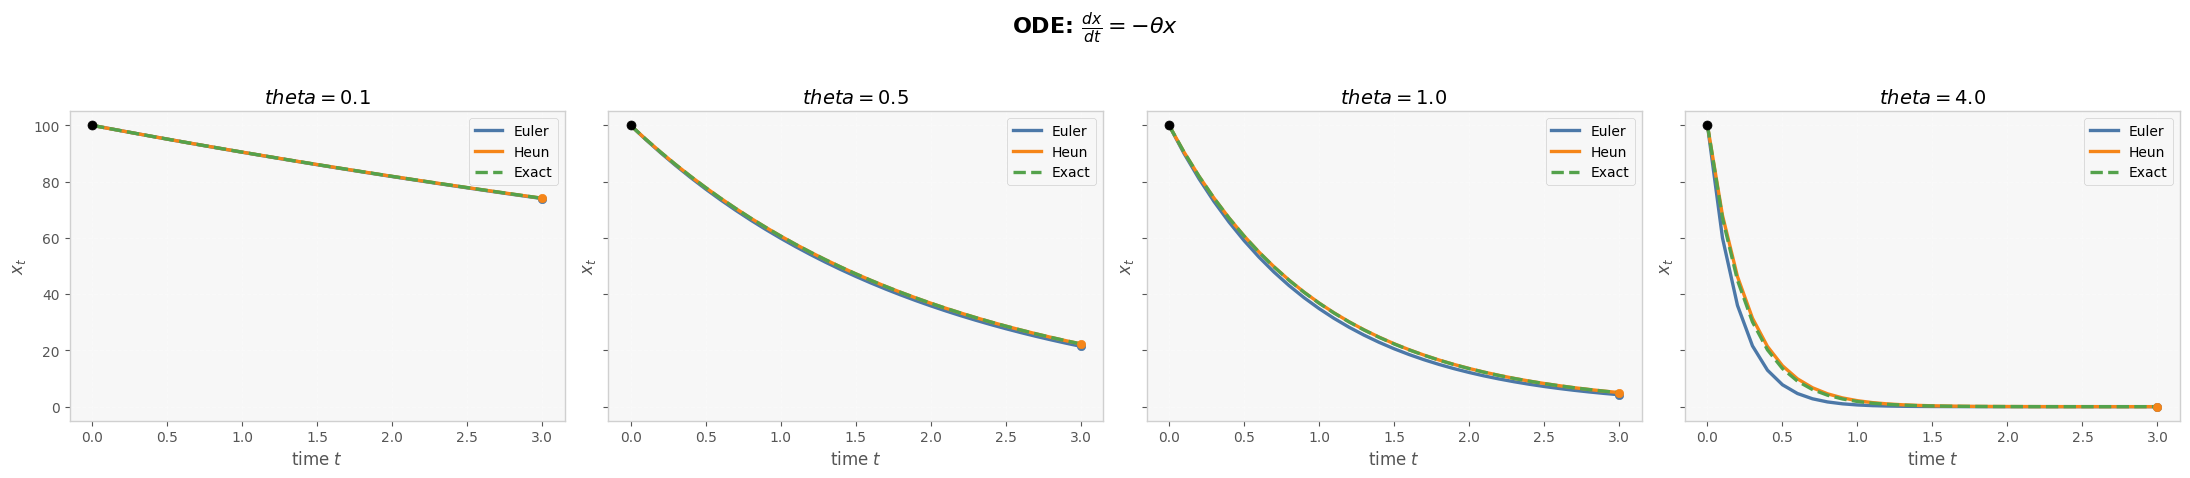

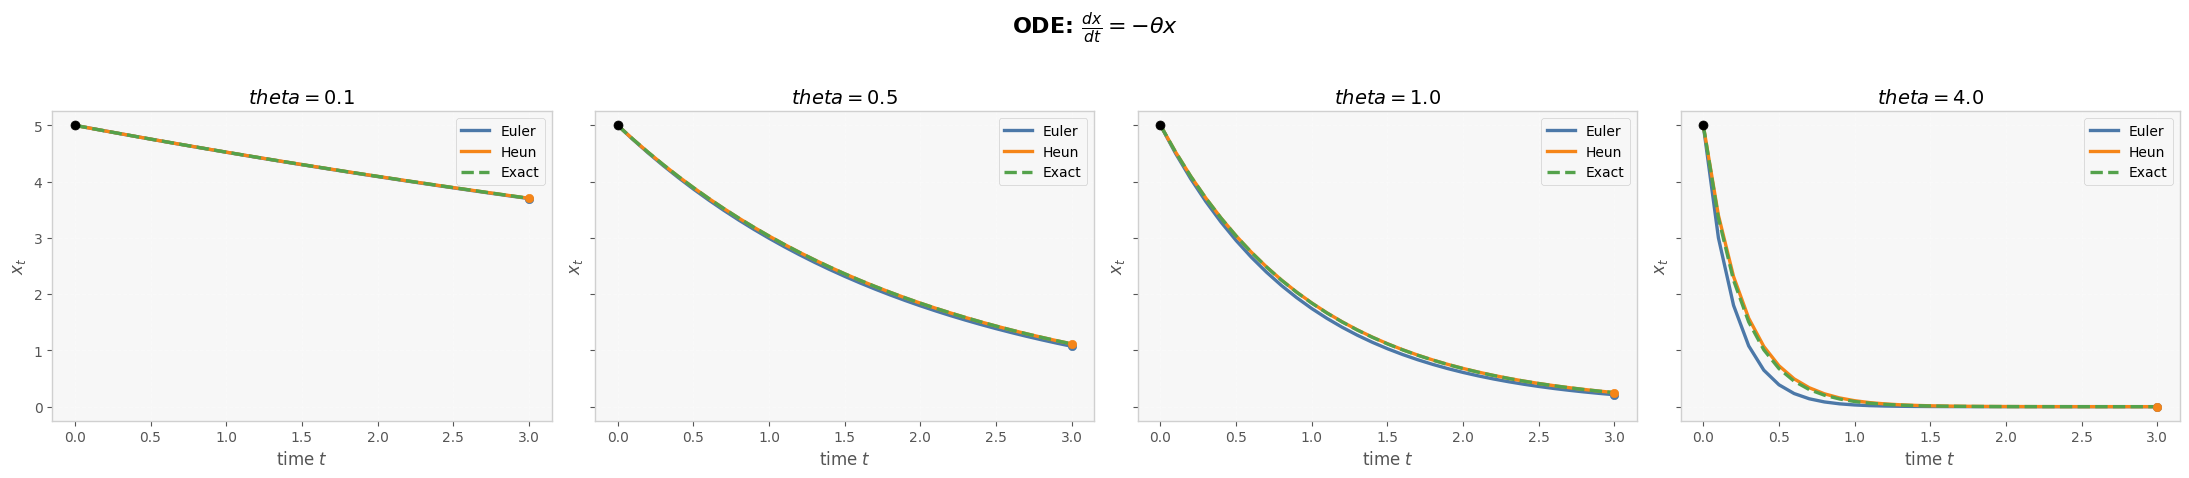

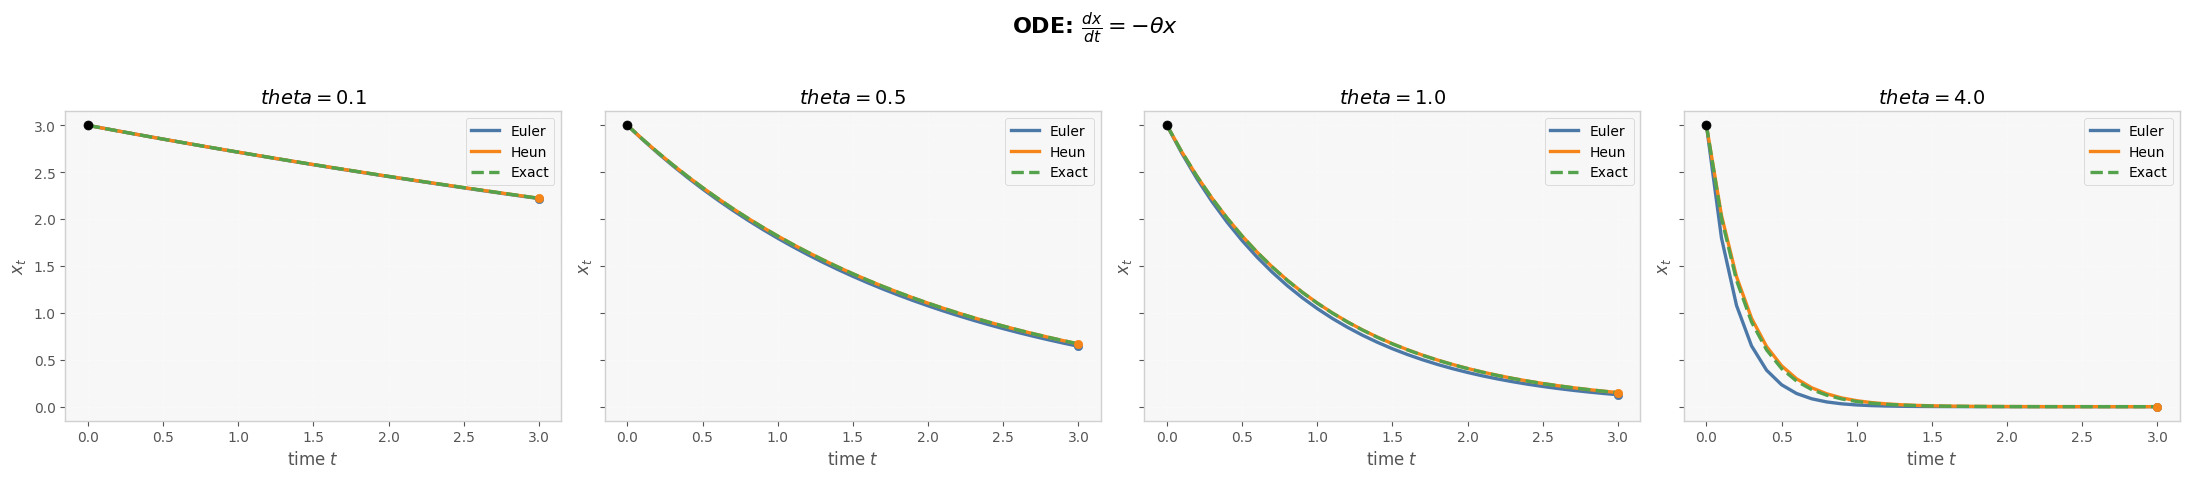

In [ ]:
def vf_decay(x, t, theta=1.0):
    return -theta * x


def exact_decay(ts: np.ndarray, x0: float, theta: float) -> np.ndarray:
    return x0 * np.exp(-theta * ts)


use_notebook_plot_style()

x0_values = [100.0, 5.0, 3.0]
thetas = [0.1, 0.5, 1.0, 4.0]

for x0 in x0_values:
    results = {}
    for theta in thetas:
        vf = lambda x, t, theta=theta: vf_decay(x, t, theta=theta)
        ts, xs_euler = simulate_ode(
            x0=x0, t0=0.0, t1=3.0, nsteps=30, vf=vf, fn=euler_step
        )
        _, xs_heun = simulate_ode(x0=x0, t0=0.0, t1=3.0, nsteps=30, vf=vf, fn=heun_step)
        results[theta] = {
            "Euler": np.asarray(xs_euler).squeeze(),
            "Heun": np.asarray(xs_heun).squeeze(),
        }

    plot_theta_grid(ts, results, x0=x0, exact_fn=exact_decay)
    plt.show()


## 2D trajectories

Next, we move from scalar dynamics to planar dynamics. The vector field now gives a direction at every point in the plane.


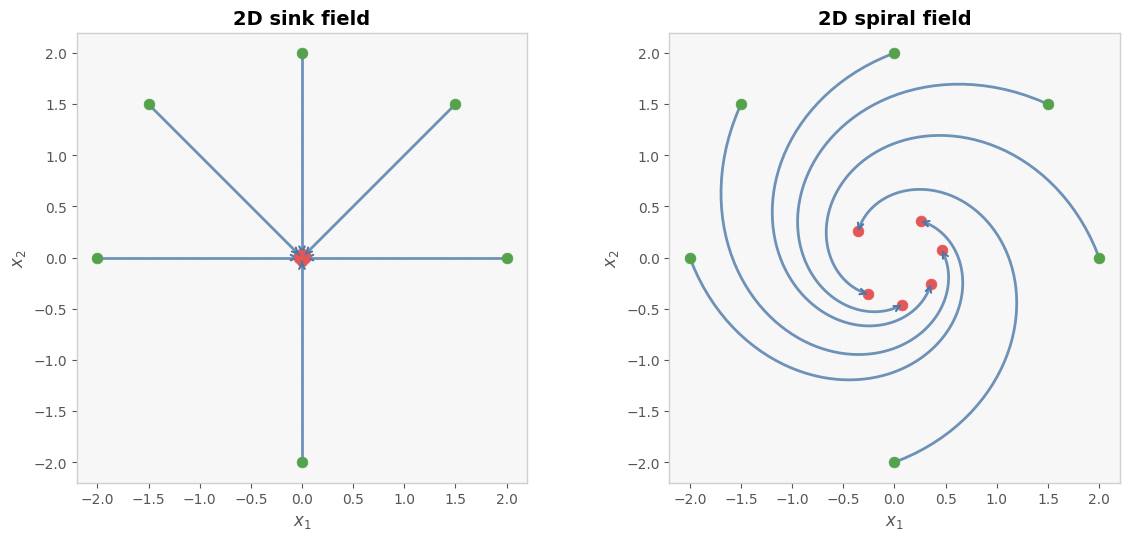

In [ ]:
def vf_sink(x, t):
    return -x


def vf_spiral(x, t):
    x1, x2 = x[..., 0], x[..., 1]
    out = np.empty_like(x)
    out[..., 0] = -0.4 * x1 - 1.0 * x2
    out[..., 1] = 1.0 * x1 - 0.4 * x2
    return out


initial_points = [
    np.array([2.0, 0.0]),
    np.array([0.0, 2.0]),
    np.array([-2.0, 0.0]),
    np.array([0.0, -2.0]),
    np.array([1.5, 1.5]),
    np.array([-1.5, 1.5]),
]

sink_trajectories = []
spiral_trajectories = []

for x0 in initial_points:
    _, xs_sink = simulate_ode(x0=x0, t0=0.0, t1=4.0, nsteps=80, vf=vf_sink)
    _, xs_spiral = simulate_ode(x0=x0, t0=0.0, t1=4.0, nsteps=80, vf=vf_spiral)
    sink_trajectories.append(xs_sink)
    spiral_trajectories.append(xs_spiral)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
plot_2d_trajectories(
    sink_trajectories, title="2D sink field", ax=axes[0], show_arrows=True
)
plot_2d_trajectories(
    spiral_trajectories, title="2D spiral field", ax=axes[1], show_arrows=True
)
fig.tight_layout()
plt.show()


## Gaussian cloud transport

This is the first step that actually looks like generative modeling: a simple source distribution gets transported through time under a deterministic flow.

A plain grid of sink-field snapshots is not very informative because a Gaussian stays Gaussian while shrinking. So below we use three complementary views:

- a few snapshot panels,
- trajectory overlays for a small subset of particles,
- and a scalar summary `mean ||x_t||` over time.


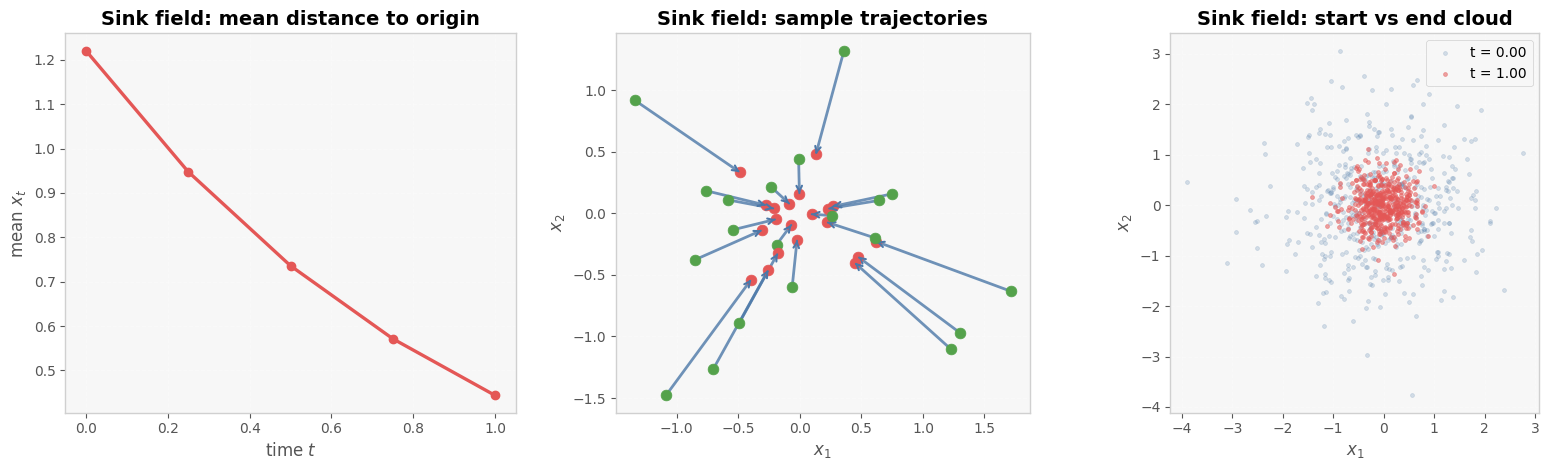

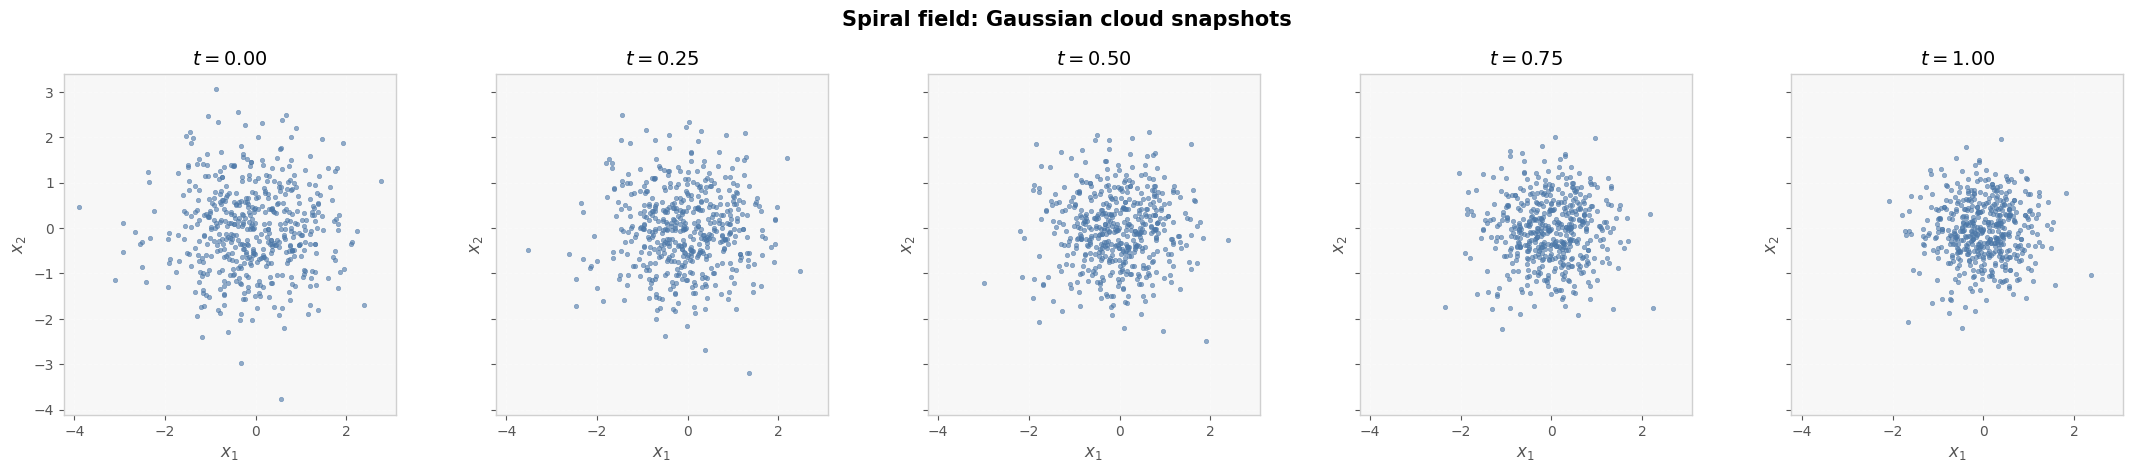

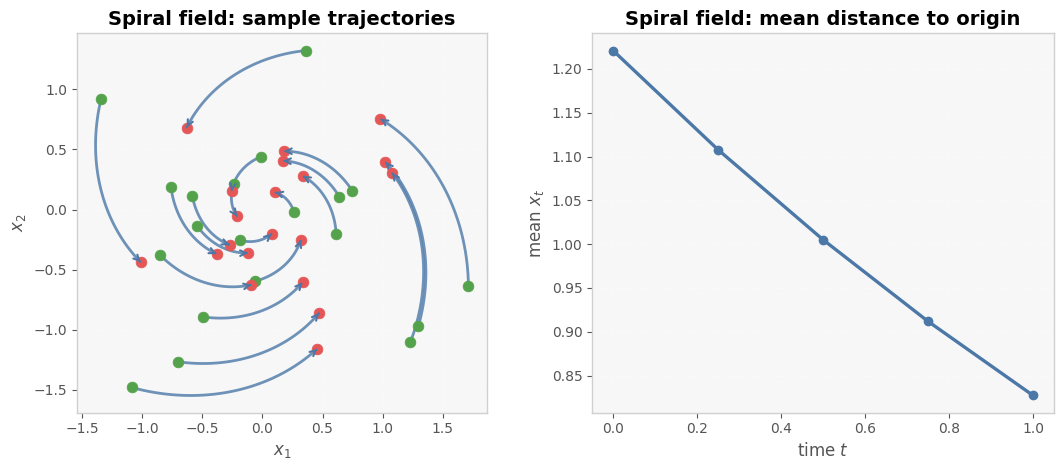

In [ ]:
rng = np.random.default_rng(0)
x0_cloud = rng.normal(size=(500, 2))
snapshot_times = [0.0, 0.25, 0.5, 0.75, 1.0]
trajectory_indices = rng.choice(len(x0_cloud), size=20, replace=False)
trajectory_times = np.linspace(0.0, 1.0, 41)

sink_clouds = []
spiral_clouds = []

for t_end in snapshot_times:
    cloud_sink = []
    cloud_spiral = []
    for x0 in x0_cloud:
        _, xs_sink = simulate_ode(
            x0=x0,
            t0=0.0,
            t1=t_end,
            nsteps=max(1, int(40 * max(t_end, 0.05))),
            vf=vf_sink,
        )
        _, xs_spiral = simulate_ode(
            x0=x0,
            t0=0.0,
            t1=t_end,
            nsteps=max(1, int(40 * max(t_end, 0.05))),
            vf=vf_spiral,
        )
        cloud_sink.append(xs_sink[-1])
        cloud_spiral.append(xs_spiral[-1])

    sink_clouds.append(np.stack(cloud_sink))
    spiral_clouds.append(np.stack(cloud_spiral))

sink_radii = np.array([np.linalg.norm(cloud, axis=1).mean() for cloud in sink_clouds])
spiral_radii = np.array(
    [np.linalg.norm(cloud, axis=1).mean() for cloud in spiral_clouds]
)

sink_trajectory_samples = []
spiral_trajectory_samples = []

for idx in trajectory_indices:
    x0 = x0_cloud[idx]
    _, xs_sink = simulate_ode(
        x0=x0, t0=0.0, t1=1.0, nsteps=len(trajectory_times) - 1, vf=vf_sink
    )
    _, xs_spiral = simulate_ode(
        x0=x0, t0=0.0, t1=1.0, nsteps=len(trajectory_times) - 1, vf=vf_spiral
    )
    sink_trajectory_samples.append(xs_sink)
    spiral_trajectory_samples.append(xs_spiral)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
axes[0].plot(snapshot_times, sink_radii, marker="o", color="#E45756")
axes[0].set_title("Sink field: mean distance to origin")
axes[0].set_xlabel(r"time $t$")
axes[0].set_ylabel(r"mean $x_t$")
axes[0].grid(True, alpha=0.3)
plot_2d_trajectories(
    sink_trajectory_samples,
    title="Sink field: sample trajectories",
    ax=axes[1],
    show_arrows=True,
)
axes[2].scatter(
    sink_clouds[0][:, 0],
    sink_clouds[0][:, 1],
    s=8,
    alpha=0.22,
    color="#4C78A8",
    label="t = 0.00",
)
axes[2].scatter(
    sink_clouds[-1][:, 0],
    sink_clouds[-1][:, 1],
    s=8,
    alpha=0.55,
    color="#E45756",
    label="t = 1.00",
)
axes[2].set_title("Sink field: start vs end cloud")
axes[2].set_xlabel(r"$x_1$")
axes[2].set_ylabel(r"$x_2$")
axes[2].set_aspect("equal")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.25)
fig.tight_layout()
plt.show()

plot_cloud_snapshots(
    spiral_clouds, snapshot_times, title="Spiral field: Gaussian cloud snapshots"
)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
plot_2d_trajectories(
    spiral_trajectory_samples,
    title="Spiral field: sample trajectories",
    ax=axes[0],
    show_arrows=True,
)
axes[1].plot(snapshot_times, spiral_radii, marker="o", color="#4C78A8")
axes[1].set_title("Spiral field: mean distance to origin")
axes[1].set_xlabel(r"time $t$")
axes[1].set_ylabel(r"mean $x_t$")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()
